In [1]:
import scipy.integrate as itg
import numpy as np
import matplotlib.pyplot as plt

## Ecuaciones de movimiento empleadas para la integración de las órbitas

Sea el vector de posición $\vec{r} = x \hat{i} + y \hat{j} + z \hat{k}$, entonces la velocidad es $\dot{\vec{r}} = \dot{x} \hat{i} + \dot{y} \hat{j} + \dot{z} \hat{k}$. De esta forma, la energía cinética $T = \frac{1}{2}m \dot{\vec{r}}^2$ es:

$T = \frac{1}{2}\left( \dot{x}^2 + \dot{y}^2 + \dot{z}^2 \right)$ (Para una partícula de prueba).

Por otro lado, la energía potencial $V$ de la partícula de prueba, está dada por $V = \Phi$. Así, la lagrangiana $L = T - V$ es:

$L = \frac{1}{2}\left( \dot{x}^2 + \dot{y}^2 + \dot{z}^2 \right) - \Phi$

Las ecuaciones de movimiento se derivan al obtener las ecuaciones de Euler - Lagrange, dadas por: 

$\frac{d}{dt}\left( \frac{\partial L}{\partial \dot{q_i}} \right) - \frac{\partial L}{\partial q_i} = 0$ con $q_i = x, y ,z$

En cada caso,

$\ddot q_i = - \frac{\partial \Phi}{\partial q_i}$

Donde además, $\Phi = \Phi_1 + \Phi_2 + \Phi_3$, cada uno siendo el potencial de la masa central, el potencial del disco y el potencial del halo, respectivamente. Entonces, $\frac{\partial \Phi}{\partial q_i} = \sum_{j=1}^3 \frac{\partial \Phi_j}{\partial q_i}$. Donde:

$\frac{\partial \Phi_1}{\partial q_i} = \frac{M_1 q_i}{(R^2 + b_1^2)^{3/2}}$

$\frac{\partial \Phi_2}{\partial q_j} = \frac{M_2 q_j}{\left\{ x^2 + y^2 + \right[ a_2 + \sqrt{z^2 + b_2^2}\left]^2 \right\}^{3/2}}$ con $q_j = x,y$

$\frac{\partial \Phi_2}{\partial z} = \frac{M_2 z\left[ a_2 + \sqrt{b^2 + z^2} \right]^2}{\sqrt{b_2^2 + z^2}(x^2 + y^2 + \left[ a_2 + \sqrt{b_2^2 + z^2} \right]^2)^{3/2}}$

$\frac{\partial \Phi_3}{\partial q_i} = \frac{M_3 q_i (R/a_3)^{1.02}}{a_3 R^2 (1 + (R/a_3)^{1.02})}$

In [2]:
def acc(v): 
    x, y, z = v[0], v[1], v[2]
    R = np.sqrt(x**2 + y**2 + z**2) # kpc units
    truncation = 100
    R = np.minimum(R, truncation)
    R  = max(R, 1e-6)
    
    # Central mass
    M1 = 606.
    b1 = 0.3873
    
    dphi_x1 =  M1*x/(x**2 + y**2 + z**2 + b1**2)**(3/2)
    dphi_y1 =  M1*y/(x**2 + y**2 + z**2 + b1**2)**(3/2)
    dphi_z1 =  M1*z/(x**2 + y**2 + z**2 + b1**2)**(3/2) 
    
    # Disk component
    M2 = 3690.
    a2 = 5.3178
    b2 = 0.25
    
    dphi_x2 = M2*x / (x**2 + y**2 + (a2 + np.sqrt(z**2 + b2**2))**2)**(3/2)
    dphi_y2 = M2*y / (x**2 + y**2 + (a2 + np.sqrt(z**2 + b2**2))**2)**(3/2)
    dphi_z2 = M2*z*(a2 + np.sqrt(z**2 + b2**2))/(np.sqrt(z**2 + b2**2)*(np.sqrt(x**2 + y**2 + (a2 + np.sqrt(z**2 + b2**2))**2))**3)
    
    # Halo
    M3 = 4615.
    a3 = 12.

    def halo(x):
        a = -(1.02*M3*(x/R))*((R/a3)**2.02)
        b = R*(1+(R/a3)**1.02)
        
        c = M3 * x * ((R/a3)**(1.02)) / (a3 * R**2)
        d = 1 + (R/a3)**(1.02)
        
        halo = c / d
        return halo
    
    dphi_x3 = halo(x)
    dphi_y3 = halo(y)
    dphi_z3 = halo(z)
    
    dphi_x = dphi_x1 + dphi_x2 + dphi_x3
    dphi_y = dphi_y1 + dphi_y2 + dphi_y3
    dphi_z = dphi_z1 + dphi_z2 + dphi_z3

    acx, acy, acz = -dphi_x, -dphi_y, -dphi_z
    return np.array([acx, acy, acz])

def f(t, state):
    x, y, z, vx, vy, vz = state
    v = np.array([x,y,z])
    ax, ay, az = acc(v)
    return np.array([vx, vy, vz, ax, ay, az])

In [3]:
def rk4_step(f, t, y, h):
    """One classical RK4 step, exactly as derived previously."""
    k1 = f(t,       y)
    k2 = f(t + h/2, y + (h/2)*k1)
    k3 = f(t + h/2, y + (h/2)*k2)
    k4 = f(t + h,   y + h*k3)
    return y + (h/6.0)*(k1 + 2*k2 + 2*k3 + k4)

def integrate_rk4(f, t0, y0, t_end, h):
    n_steps = int(np.ceil((t_end - t0)/h))
    ts = np.linspace(t0, t0 + n_steps*h, n_steps+1)
    ys = np.zeros((n_steps+1, len(y0)))
    ys[0] = y0
    y = y0.copy()
    for i in range(1, n_steps+1):
        y = rk4_step(f, ts[i-1], y, h)
        ys[i] = y
    return ts, ys

In [14]:
kpc = 1.0                 # already in code length units
kms_to_code = 1.0/10.0    # 1 code velocity unit = 10 km/s

x0, y0_, z0 = 8.0, 0.0, 0.021         # kpc: R ~ 8 kpc, slightly above the plane
vx0, vy0, vz0 = 0.0*kms_to_code, 220.0*kms_to_code, 0.0*kms_to_code  # km/s -> code units

state0 = np.array([x0, y0_, z0, vx0, vy0, vz0])

# --- Integrate for 5 Gyr ---
time_unit_Gyr = 0.0978
t_end_Gyr = 5
t_end = t_end_Gyr / time_unit_Gyr    # convert Gyr -> code time units
h = 0.005
ts, ys = integrate_rk4(f, 0.0, state0, t_end, h)

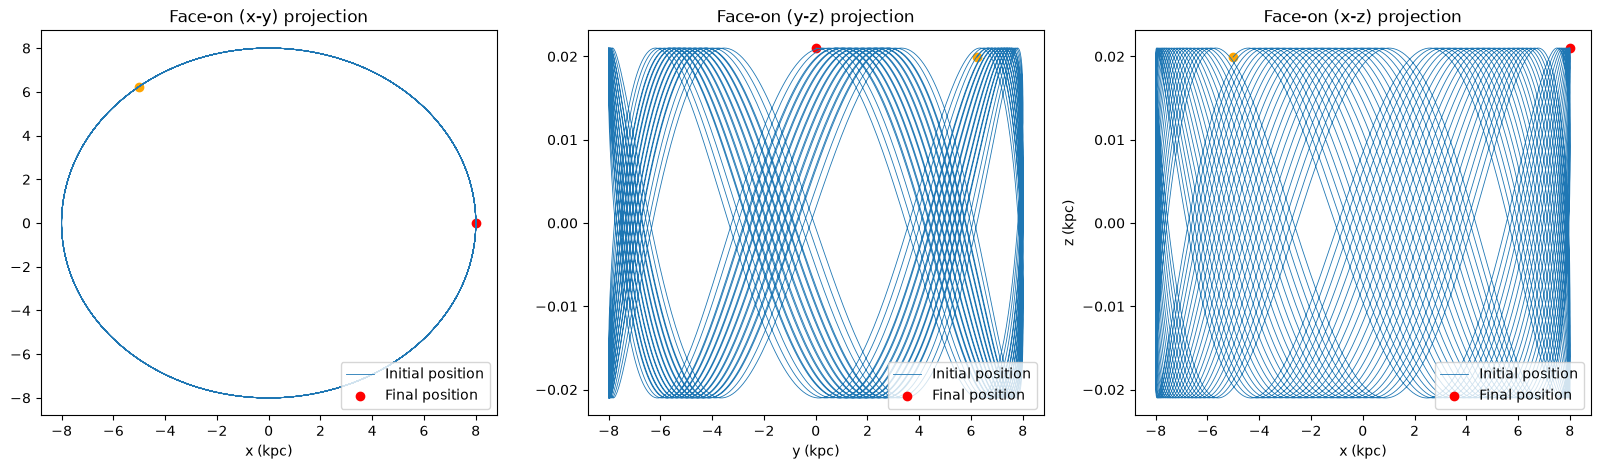

In [15]:
fig, axes = plt.subplots(1, 3, figsize = (20,5))

axes[0].plot(ys[:,0], ys[:,1], lw=0.6, label = "Initial position")
axes[0].scatter(state0[0], state0[1], color = "r", label = "Final position")
axes[0].scatter(ys[-1,0], ys[-1,1], color = "orange")
axes[0].set_xlabel('x (kpc)'); plt.ylabel('y (kpc)')
axes[0].set_title('Face-on (x-y) projection')
axes[0].legend(loc = 4)

axes[1].plot(ys[:,1], ys[:,2], lw=0.6, label = "Initial position")
axes[1].scatter(state0[1], state0[2], color = "r", label = "Final position")
axes[1].scatter(ys[-1,1], ys[-1,2], color = "orange")
axes[1].set_xlabel('y (kpc)'); plt.ylabel('z (kpc)')
axes[1].set_title('Face-on (y-z) projection')
axes[1].legend(loc = 4)

axes[2].plot(ys[:,0], ys[:,2], lw=0.6, label = "Initial position")
axes[2].scatter(state0[0], state0[2], color = "r", label = "Final position")
axes[2].scatter(ys[-1,0], ys[-1,2], color = "orange")
axes[2].set_xlabel('x (kpc)'); plt.ylabel('z (kpc)')
axes[2].set_title('Face-on (x-z) projection')
axes[2].legend(loc = 4)

plt.savefig("./images/orbits_each_plane.png")
plt.show()

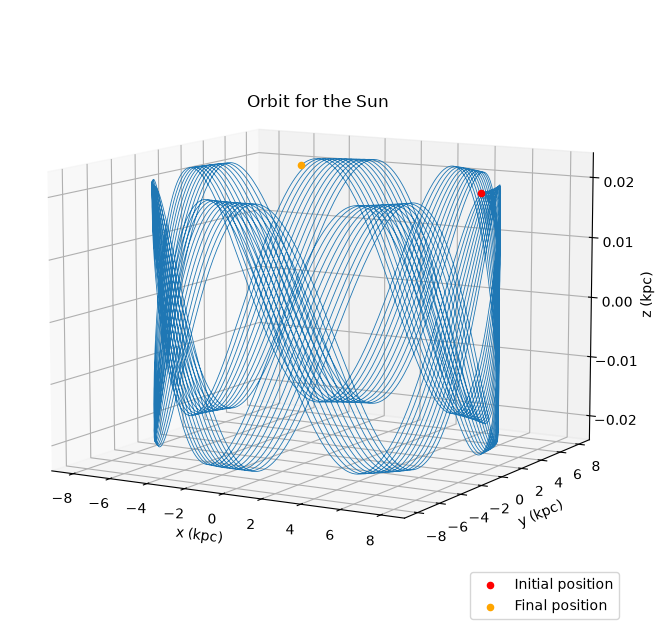

In [16]:
fig = plt.figure(figsize = (8,8),)
ax = fig.add_subplot(projection='3d')
ax.scatter(state0[0], state0[1], state0[2], color = "r", label = "Initial position")
ax.scatter(ys[-1,0], ys[-1,1], ys[-1,2], color = "orange", label = "Final position")
ax.plot(ys[:,0], ys[:,1], ys[:,2], lw = 0.6)
ax.view_init(elev=10, azim = None, roll=0)
ax.set_xlabel("x (kpc)")
ax.set_ylabel("y (kpc)")
ax.set_zlabel("z (kpc)")
ax.legend(loc = 4)
ax.set_title("Orbit for the Sun", y = 0.95, pad = -14)
plt.savefig("./images/órbita3d.png")
plt.show()